# Object Detection — Standalone Notebook

Same TF Hub SSD MobileNet V2 model as the Reachy Mini app, but using your laptop's webcam directly.
No Reachy hardware needed — useful for testing the detection pipeline independently.

## 1. Install Dependencies

In [1]:
!pip install tensorflow tensorflow-hub opencv-python numpy Pillow

  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.4 kB)
  Using cached grpcio-1.80.0-cp312-cp312-macosx_11_0_universal2.whl.metadata (3.8 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached wheel

## 2. Load the Model

SSD MobileNet V2 trained on Open Images V4 — fast enough for real-time on CPU (~10 FPS).

In [11]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import time
from IPython.display import display, clear_output, HTML
from PIL import Image

MODEL_HANDLE = "https://tfhub.dev/google/openimages_v4/ssd/mobilenet_v2/1"

print(f"TensorFlow version: {tf.__version__}")
print("Loading model (first time downloads ~30MB)...")

detector = hub.load(MODEL_HANDLE)
print("Model loaded!")

TensorFlow version: 2.21.0
Loading model (first time downloads ~30MB)...
INFO:tensorflow:Saver not created because there are no variables in the graph to restore


INFO:tensorflow:Saver not created because there are no variables in the graph to restore


Model loaded!


## 3. Detection Helper Functions

Same logic as `detector.py` in the Reachy app.

In [20]:
MIN_SCORE = 0.3
MAX_DETECTIONS = 10


def detect_objects(frame_bgr, min_score=0.5, max_detections=10):
    # Convert BGR to RGB
    rgb = frame_bgr[:, :, ::-1]
    img_tensor = tf.image.convert_image_dtype(rgb, tf.float32)[tf.newaxis, ...]

    # Use the model's signature for inference
    results = detector.signatures['default'](img_tensor)

    # Convert tensors to numpy arrays and ensure proper shape
    boxes = np.array(results["detection_boxes"])
    scores = np.array(results["detection_scores"])
    class_labels = np.array(results["detection_class_entities"])
    
    # Flatten if needed (remove batch dimension)
    if boxes.ndim > 2:
        boxes = boxes[0]
    if scores.ndim > 1:
        scores = scores[0]
    if class_labels.ndim > 1:
        class_labels = class_labels[0]
    
    # Ensure arrays are 1D for scores and labels
    scores = np.atleast_1d(scores)
    
    # Filter by score and limit detections
    indices = [i for i, score in enumerate(scores) if score >= min_score][:max_detections]
    
    # Build detection list with proper format for draw_detections
    detections = []
    for idx in indices:
        ymin, xmin, ymax, xmax = boxes[idx]
        label = class_labels[idx].decode('utf-8') if isinstance(class_labels[idx], bytes) else str(class_labels[idx])
        detections.append({
            "box": [ymin, xmin, ymax, xmax],
            "score": float(scores[idx]),
            "label": label
        })

    return detections



def draw_detections(frame_bgr, detections):
    """Draw bounding boxes and labels on a frame."""
    h, w = frame_bgr.shape[:2]
    annotated = frame_bgr.copy()

    for det in detections:
        ymin, xmin, ymax, xmax = det["box"]
        x1, y1 = int(xmin * w), int(ymin * h)
        x2, y2 = int(xmax * w), int(ymax * h)

        color = (0, 255, 0)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

        label = f"{det['label']} {det['score']:.0%}"
        font_scale = 0.6
        thickness = 2
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
        cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), thickness)

    return annotated


print("Helper functions ready.")

Helper functions ready.


## 4. Test on a Single Frame

Grab one frame from your webcam and run detection.

Frame captured: (1080, 1920, 3)
Inference time: 0.03s (37.0 FPS)
Found 2 objects:
  - Human face: 64%
  - Person: 50%


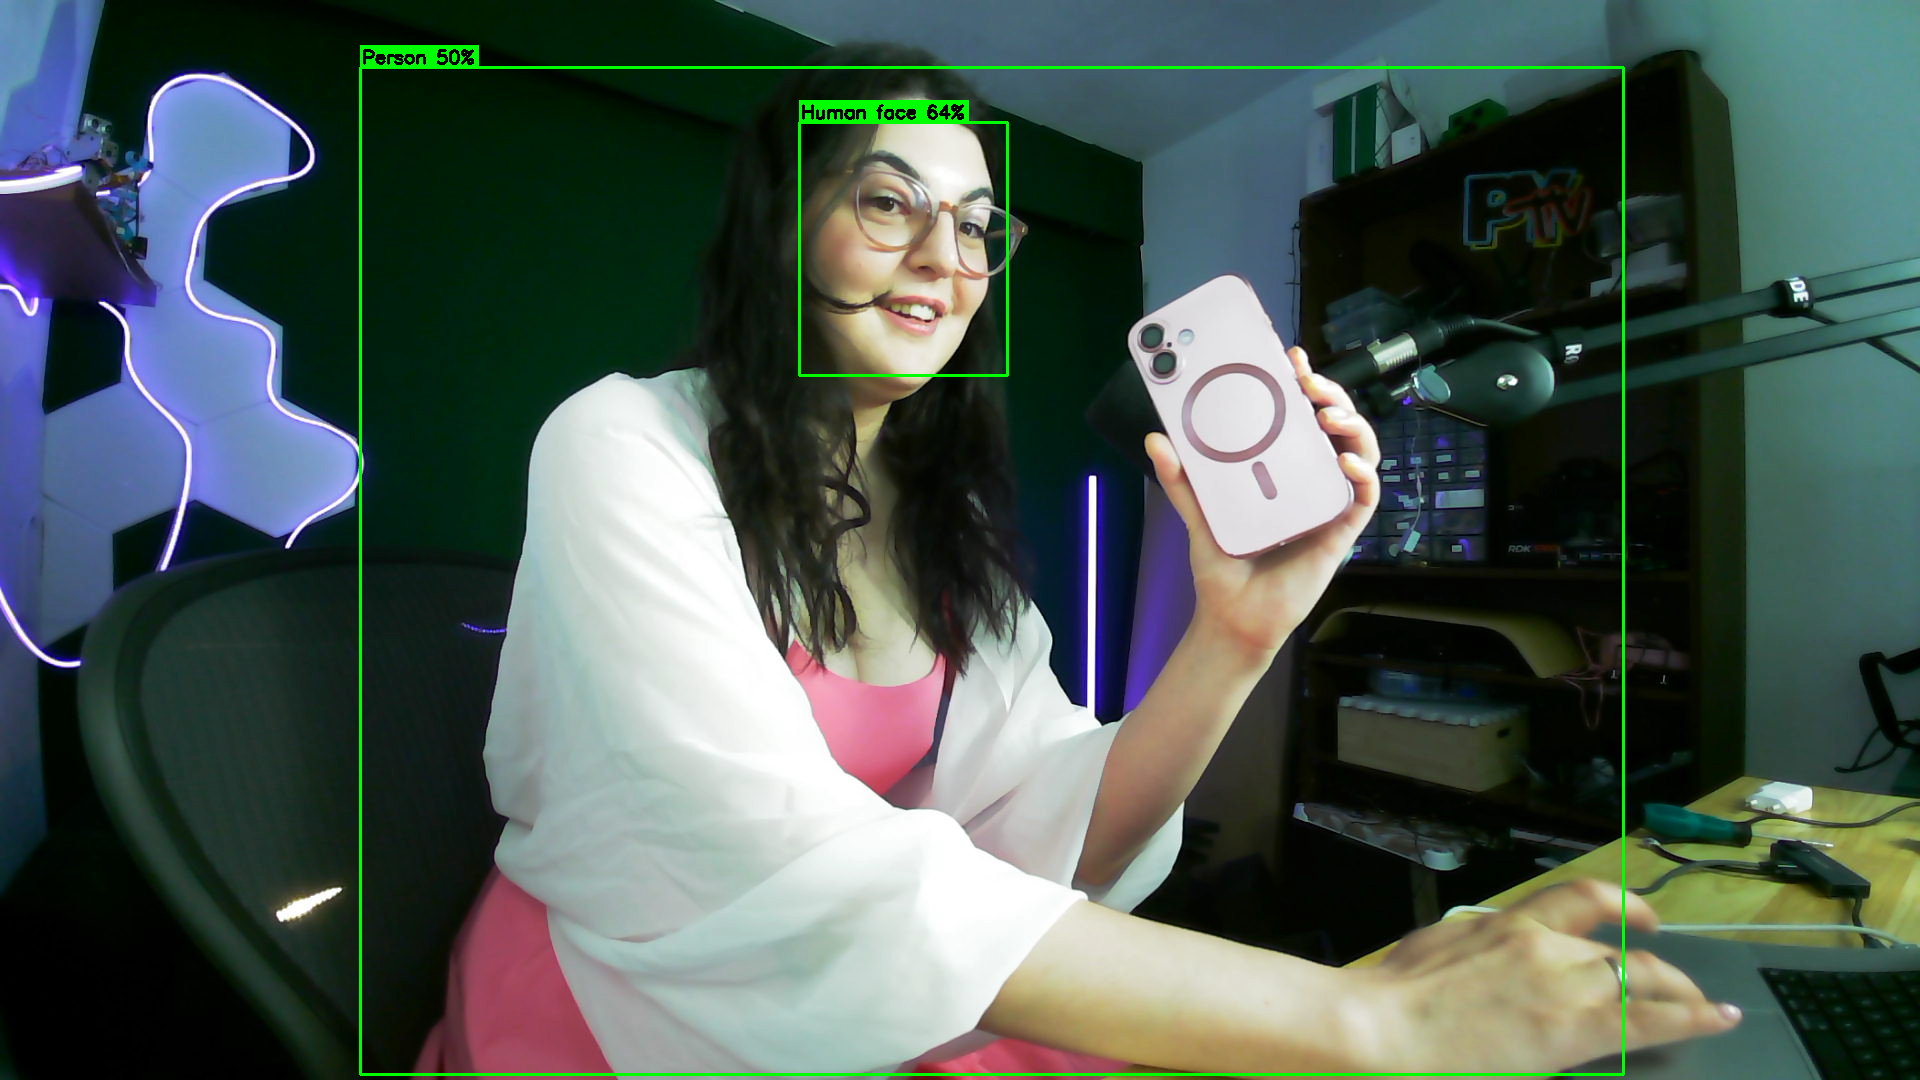

In [28]:
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if not ret:
    print("ERROR: Could not access webcam. Make sure no other app is using it.")
else:
    print(f"Frame captured: {frame.shape}")

    t0 = time.time()
    detections = detect_objects(frame)
    elapsed = time.time() - t0

    print(f"Inference time: {elapsed:.2f}s ({1/elapsed:.1f} FPS)")
    print(f"Found {len(detections)} objects:")
    for d in detections:
        print(f"  - {d['label']}: {d['score']:.0%}")

    annotated = draw_detections(frame, detections)
    # Convert BGR to RGB for display
    display(Image.fromarray(annotated[:, :, ::-1]))

## 5. Live Detection Loop

Continuous detection from your webcam, displayed inline. **Interrupt the kernel to stop.**

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Could not open webcam.")
else:
    print("Running live detection... (interrupt kernel to stop)")
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            t0 = time.time()
            detections = detect_objects(frame)
            fps = 1.0 / max(time.time() - t0, 0.001)

            annotated = draw_detections(frame, detections)

            # Add FPS overlay
            cv2.putText(annotated, f"{fps:.1f} FPS", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

            # Display in notebook
            clear_output(wait=True)
            rgb = annotated[:, :, ::-1]
            display(Image.fromarray(rgb))

            labels = ", ".join(f"{d['label']} ({d['score']:.0%})" for d in detections)
            print(f"{fps:.1f} FPS | {len(detections)} objects: {labels or 'none'}")

    except KeyboardInterrupt:
        print("Stopped.")
    finally:
        cap.release()
        print("Camera released.")

## 6. (Optional) Live Detection with OpenCV Window

Opens a native window — smoother than inline display. Press **q** to quit.

In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Could not open webcam.")
else:
    print("Press 'q' in the OpenCV window to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t0 = time.time()
        detections = detect_objects(frame)
        fps = 1.0 / max(time.time() - t0, 0.001)

        annotated = draw_detections(frame, detections)
        cv2.putText(annotated, f"{fps:.1f} FPS", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

        cv2.imshow("Object Detection", annotated)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Done.")